# Inhalt aus: `B710-vision-keras-mnist.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Computer Vision - Convolutional Neural Network (CNN) - MNIST
</b></font> </br></p>

---

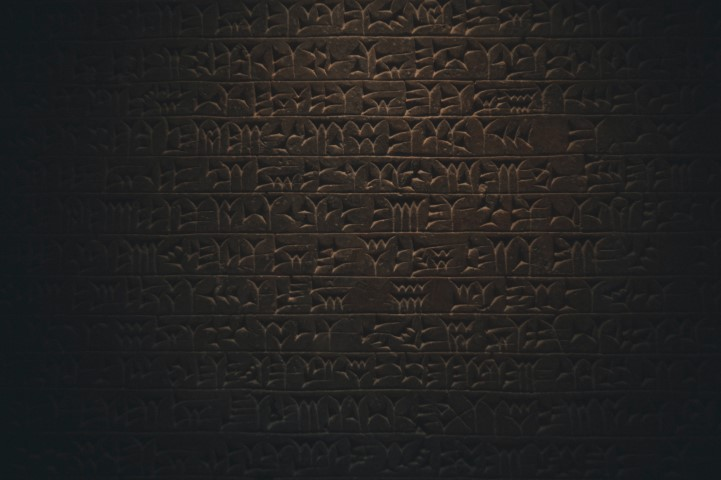

Foto von <a href="https://unsplash.com/@vonshnauzer?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Egor Myznik</a> auf <a href="https://unsplash.com/de/fotos/of_azYsANQY?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>



# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
import numpy as np

from sklearn.metrics import accuracy_score

import keras
from keras.models import Sequential, load_model
from keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---


Die MNIST-Datenbank ( Modified National Institute of Standards and Technology database ) ist eine große Datenbank mit handgeschriebenen Ziffern, die üblicherweise zum Trainieren verschiedener Bildverarbeitungssysteme verwendet wird.

Die MNIST-Datenbank mit handgeschriebenen Ziffern hat einen Trainingssatz von 60.000 Beispielen und einen Testsatz von 10.000 Beispielen mit jeweils  28x28 Pixel.







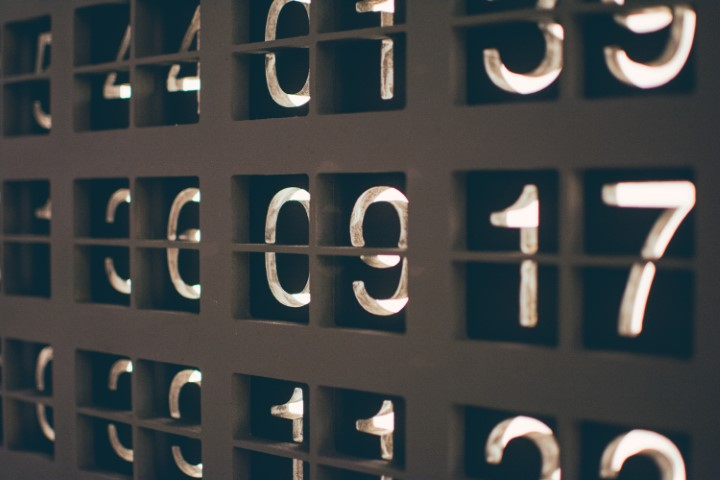

Foto von <a href="https://unsplash.com/@nhillier?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Nick Hillier</a> auf <a href="https://unsplash.com/de/fotos/yD5rv8_WzxA?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>


In [ ]:
(data_train, target_train), (data_test, target_test) = keras.datasets.mnist.load_data()

In [ ]:
data_train.shape, target_train.shape, data_test.shape, target_test.shape


<p><font color='black' size="5">
Anzeigen eines Bildes als Matrix der Pixelwerte
</font></p>

In [ ]:
test_index = 333
image = DataFrame(data_train[test_index])

In [ ]:
image.style.set_properties(**{"font-size": "6pt"}).background_gradient("Greys")

In [ ]:
plt.imshow(data_train[test_index].reshape((28, 28)))

<p><font color='black' size="5">
Anzeigen der ersten 25 Bilder
</font></p>

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(data_train[i].reshape((28, 28)))
    plt.title("Digit:{}".format(target_train[i]))
    label_index = int(target_train[i])
plt.show()

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Numpy
</font></p>

In [ ]:
np.info(data_train)

In [ ]:
np.min(data_train), np.max(data_train)

In [ ]:
np.info(target_train)

In [ ]:
np.min(target_train), np.max(target_train)

# **2 | Prepare**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Skalieren der Daten (0,1)
</font></p>

In [ ]:
data_train = data_train.astype("float32") / 255
data_test = data_test.astype("float32") / 255

<p><font color='black' size="5">
Modellparameter Bildwerte
</font></p>

In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

<p><font color='black' size="5">
Konvertierung einer Klasse (Ganzzahlen 0-9) in einen binären Klassenvektor (0, 1)
</font></p>

In [ ]:
target_train_ = keras.utils.to_categorical(target_train, num_classes)
target_test_ = keras.utils.to_categorical(target_test, num_classes)

# **3 | Modeling**
---

<p><font color='black' size="5">
Modellierung eines Neuronalen Netzes
</font></p>

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font color='black' size="5">
Modellaufbau
</font></p>

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

<p><font color='black' size="5">
Einfaches Layer-Diagramm
</font></p>

In [ ]:
model.summary()

In [ ]:
# Visualisierung neuronales Netz
plot_model(
    model,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")

<p><font color='black' size="5">
Training
</font></p>


In [ ]:
epochs_ = 10
batch_size_ = 256
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(
    data_train,
    target_train_,
    batch_size=batch_size_,
    epochs=epochs_,
    validation_split=0.2,
)

In [ ]:
print(model.history.params)
print(model.history.history.keys())

<p><font color='black' size="5">
Loss-Entwickung
</font></p>

In [ ]:
import plotly.express as px

title_ = "Loss-Entwicklung"
px.line(
    y=model.history.history["loss"],
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
target_train_pred_ = tf.argmax(target_train_pred, axis=1).numpy()
acc_train = accuracy_score(target_train, target_train_pred_) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
target_test_pred_ = tf.argmax(target_test_pred, axis=1).numpy()
acc_test = accuracy_score(target_test, target_test_pred_) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}")

<p><font color='black' size="5">
Einzelne Vorhersage
</font></p>

In [ ]:
target_test_pred_[0]

In [ ]:
test_index = 0
image = DataFrame(data_test[test_index])

In [ ]:
image.style.set_properties(**{"font-size": "6pt"}).background_gradient("Greys")

In [ ]:
plt.imshow(data_test[test_index].reshape((28, 28)))

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B715-vision-yolo.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Special Pre-Trained Models - CV - Object Detection - YOLO
</b></font> </br></p>

---


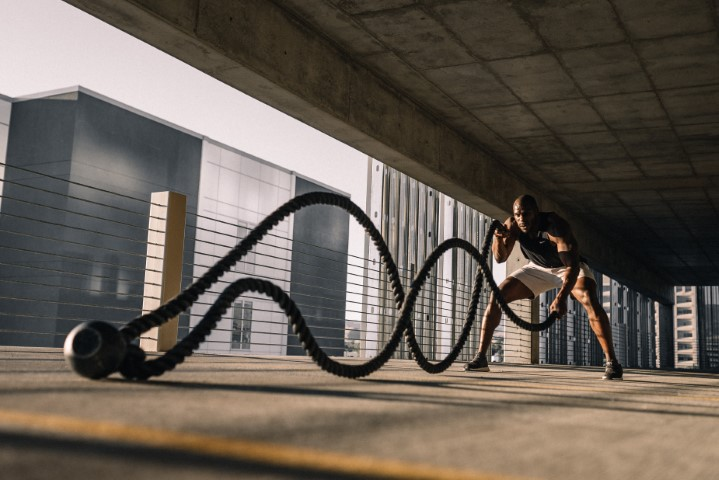

Foto von <a href="https://unsplash.com/@karsten116?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Karsten Winegeart</a> auf <a href="https://unsplash.com/de/s/fotos/Training?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
  

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system --prerelease allow ultralytics

In [ ]:
# Import
from ultralytics import YOLO

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---



+ Man sollte verstehen, für welche Geschäftsanforderungen das vortrainierte Modell geeignet sein könnte und ob es eine bessere Alternative zum Training eines neuen Modells von Grund auf darstellt.

+ Auch wenn das Modell bereits trainiert ist, ist es wichtig zu verstehen, welche Daten für das Training verwendet wurden und wie die Eingabe- und Ausgabeformate des Modells aussehen.

# **2 | Prepare**

---

Die Daten, die dem vortrainierten Modell zugeführt werden, müssen möglicherweise in ein Format umgewandelt werden, das das Modell versteht. Dies kann beinhalten, die Daten zu normieren, fehlende Werte zu behandeln oder Kategorien zu kodieren.

# **3 | Modeling**
---



An dieser Stelle wird das vortrainierte Modell importiert. Man könnte auch überlegen, ob das Modell weiter auf spezifischen Daten (Fine-Tuning) trainiert werden sollte.

<p><font color='black' size="5">
Install & Import
</font></p>


[ultralytics](https://ultralytics.com/)

[GitHub](https://github.com/ultralytics/ultralytics)

In [ ]:
model = YOLO("yolo11n.pt")

# 4 | Evaluate
---


Es ist wichtig zu bewerten, wie gut das vortrainierte Modell in der spezifischen Geschäftsumgebung funktioniert. Es könnte sein, dass trotz Vor-Training Anpassungen oder ein anderes Modell benötigt wird.

# **5 | Deploy (Apply)**
---

Das vortrainierte Modell wird in die Produktionsumgebung integriert. Hier ist es auch wichtig, ständig die Performance des Modells zu überwachen, da sich die Daten über die Zeit ändern könnten.

<p><font color='black' size="5">
Image
</font></p>

In [ ]:
# Datei von GitHub kopieren
!curl -L https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/people.jpg -o image.jpg

In [ ]:
_ = model.predict(source="/content/image.jpg", save=True, conf=0.2, save_txt=True)

**Nach Code-Ausführung:**

Verzeichnis: /content/runs/detect/predict/image.jpg



<p><font color='black' size="5">
Video
</font></p>

In [ ]:
# Datei von GitHub kopieren
!curl -L https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/pexels-pixabay-people.mp4 -o video.mp4

Video by Pixabay: https://www.pexels.com/video/video-of-people-walking-855564/

In [ ]:
_ = model.predict(source="/content/video.mp4", save=True, conf=0.25, save_txt=True)

**Nach Code-Ausführung:**    


Verzeichnis: /content/runs/detect/predict/video.avi   

# **A | Conclusion**
---

Zusammenfassend lässt sich sagen, dass vortrainierte Modelle in das Prozessmodell integriert werden können, indem man sie in der ``Modeling-Phase`` einführt, in der ``Deploy-Phase`` anwendet, aber alle anderen Phasen grundsätzlich weiterhin relevant bleiben.

# Inhalt aus: `B720-nlp-keras-spam.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Natural Language Processing  - Neural Network - SPAM or HAM
</b></font> </br></p>

---

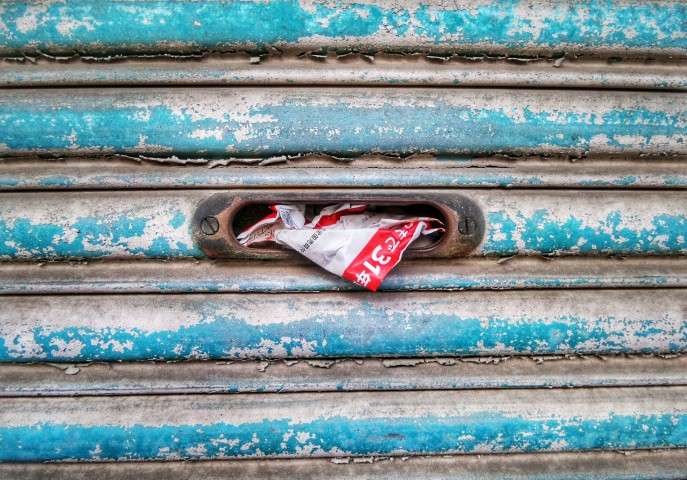

Foto von <a href="https://unsplash.com/@possessedphotography?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Possessed Photography</a> auf <a href="https://unsplash.com/de/fotos/oIMXkEuiXpc?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>


# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
import numpy as np
from pandas import read_csv, DataFrame, concat

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

import keras
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---


Diese DataSet wurde aus Recherchequellen im Internet zusammengestellt: -> Eine Sammlung von 425 SMS-Spam-Nachrichten wurde manuell von der Grumbletext-Website extrahiert. Dies ist ein britisches Forum, in dem Mobiltelefonnutzer öffentliche Behauptungen über SMS-Spam-Nachrichten aufstellen, die meisten von ihnen, ohne die empfangene Spam-Nachricht selbst zu melden. Die Identifizierung des Textes von Spam-Nachrichten in den Ansprüchen ist eine sehr schwierige und zeitaufwändige Aufgabe und erforderte das sorgfältige Scannen von Hunderten von Webseiten.

Das Ziel ist es, ein Vorhersagemodell zu erstellen, das bestimmt, ob eine Textnachricht Spam oder Ham ist.


[Info](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

[DataSet](https://archive-beta.ics.uci.edu/dataset/228/sms+spam+collection)






Foto von <a href="https://unsplash.com/@nhillier?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Nick Hillier</a> auf <a href="https://unsplash.com/de/fotos/yD5rv8_WzxA?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["class", "msg"],
)
data = df["msg"].copy()
target = df["class"].replace(["ham", "spam"], [0, 1]).copy()

In [ ]:
data.shape, target.shape

In [ ]:
data[26]  # Lol, du bist immer so überzeugend (lol = Laughing out loud)

# **2 | Prepare**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Tokenizer
</font></p>

Der Datensatz wird tokenisiert (`Tokenizer`). Jedem Wort wird eine eindeutige Nummer zugewiesen - die für das neuronale Netzwerk erforderlich ist, um die Eingabe zu interpretieren.

[Tokenizer](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer)

In [ ]:
num_words_ = 10000  # die maximale Anzahl der zu behaltenden Wörter, basierend auf der Worthäufigkeit
oov_tok_ = "<OOV>"  # wird zu word_index hinzugefügt & und bei fehlenden Wörte bei text_to_sequence-Aufrufen verwendet

In [ ]:
tokenizer = Tokenizer(num_words=num_words_, oov_token=oov_tok_)
tokenizer.fit_on_texts(data)
word_index = tokenizer.word_index

In [ ]:
type(word_index), len(word_index)

In [ ]:
[(key, value) for key, value in word_index.items()][3019:3024]

<p><font color='black' size="5">
Text 2 Sequenz
</font></p>

Diese Tokens (Wörter) werden dann in Sequenzen sortiert, um sicherzustellen, dass die Tokens für jedes Wort der richtigen Reihenfolge folgen, wie sie von jedem Satz vorgegeben wird.


[text_to_word_sequence](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence)

In [ ]:
sequences = tokenizer.texts_to_sequences(data)

In [ ]:
type(sequences), len(sequences)

In [ ]:
sequences[26]

<p><font color='black' size="5">
Padding
</font></p>

Damit jeder Satz gleich lang ist, werden am Ende eines Satzes Nullen einfügt. Dies ist erforderlich, wenn ein Satz länger als ein anderer ist, da jeder Satz zum Zweck der Analyse durch das RNN gleich lang sein muss.

[pad_sequence](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences)

In [ ]:
max_length = 100  # optional, maximale Länge der Sequenzen
trunc_type = "post"  # Entfernt Worte aus Sequenzen, die größer als maxlen sind, entweder am Anfang oder am Ende der Sequenzen
padding_type = "post"  # Auffüllen entweder vor oder nach jeder Sequenz

In [ ]:
data_padded = pad_sequences(
    sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type
)

In [ ]:
data_padded[26]

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data_padded, target, test_size=0.2, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">
Modellierung eines Neuronalen Netzes
</font></p>

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

[Core layers](https://keras.io/api/layers/core_layers/)
[Reshaping layers](https://keras.io/api/layers/reshaping_layers/)
[Layer activation functions](https://keras.io/api/layers/activations/)


<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font color='black' size="5">
Modellaufbau
</font></p>

In [ ]:
input_dim_ = num_words_
output_dim_ = 16  # semantische "Tiefe" - Dimensionen Embeddings

In [ ]:
model = Sequential()
model.add(Embedding(input_dim_, output_dim_, input_length=max_length))
model.add(Flatten())
model.add(Dense(6, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

<p><font color='black' size="5">
Einfaches Layer-Diagramm
</font></p>

In [ ]:
model.summary()

In [ ]:
# Visualisierung neuronales Netz
model.build(input_shape=(None, max_length)) # Build the model
plot_model(
    model,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")

<p><font color='black' size="5">
Training
</font></p>


In [ ]:
epochs_ = 10
model.fit(data_train, target_train, validation_split=0.2, epochs=epochs_)

In [ ]:
print(model.history.params)
print(model.history.history.keys())

<p><font color='black' size="5">
Loss-Entwickung
</font></p>

In [ ]:
title_ = "Loss-Entwicklung"
px.line(
    y=model.history.history["loss"],
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

In [ ]:
target_train_pred_ = np.around(target_train_pred, 0)
target_test_pred_ = np.around(target_test_pred, 0)

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred_)
display_labels_ = ["No Spam", "Spam"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(
    classification_report(target_test, target_test_pred_, target_names=display_labels_)
)

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred_) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred_) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%")

<p><font color='black' size="5">
Real vs. Predict
</font></p>

In [ ]:
type(target_test_pred)

In [ ]:
for row in range(200, 210):
    print(
        f"Real:  {np.array(target_test)[row]} Pred: {float(target_test_pred_[row]):.2f}"
    )

In [ ]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])


def decode_review(text):
    return " ".join([reverse_word_index.get(i, "") for i in text])

In [ ]:
for row in range(200, 210):
    print(
        "Real: ",
        np.array(target_test)[row],
        "Pred: ",
        int(np.around(float(target_test_pred_[row]), 0)),
        " -- ",
        decode_review(data_test[row]),
        sep=" ",
    )

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B730-ts-keras-wetter.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Time Series Analysis  - Recurrent Neural Network & LSTM - Weather Australia
</b></font> </br></p>

---

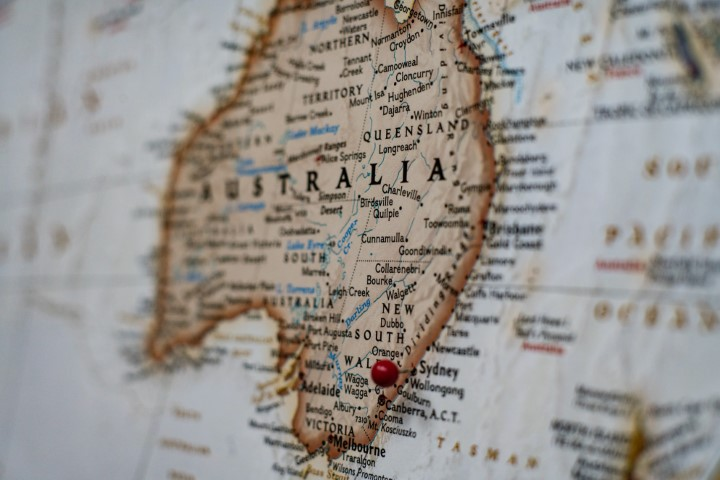

Foto von <a href="https://unsplash.com/@joey_csunyo?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Joey Csunyo</a> auf <a href="https://unsplash.com/de/fotos/2EGuIR00UTk?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
  
  

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

from keras.models import Sequential, load_model
from keras.layers import Input, LSTM, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import plotly.express as px

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---   


Dieser Datensatz enthält ungefähr 10 Jahre Wetterbeobachtungen von Hobart in Australien.

Die `Mittlere Temperatur` ist die vorherzusagende Zielvariable.
Prognostizieren die `Mittlere Temperatur`, indem Sie das Modelle mit der Zielvariablen trainieren.


[Info](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)

[DataSet](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)





In [ ]:
data = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/weather_hobart.csv"
)

<p><font color='black' size="5">
EDA (Exploratory Data Analysis)   
</font></p>

<p><font color='black' size="4">
Visualisierung der Daten
</font></p>

In [ ]:
fig = px.line(
    data, x="YearMonth", y="MedTemp", title="Weather Hobart", width=1000, height=500
)
fig.show()

# **2 | Prepare**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Übergreifende Parameter
</font></p

In [ ]:
past_steps = 12
future_steps = 1
num_features = 1


<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data.MedTemp, data.MedTemp, test_size=0.2, shuffle=False
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

In [ ]:
fig = px.line(
    data, x="YearMonth", y="MedTemp", title="Weather Hobart", width=1000, height=500
)
fig.add_vline(
    x=data.YearMonth[target_train.shape[0]],
    line_width=3,
    line_dash="dash",
    line_color="red",
)
fig.show()


<p><font color='black' size="5">
Aufbau der Zeitscheiben
</font></p>

In [ ]:
generator = TimeseriesGenerator(
    target_train.values, target_train.values, length=past_steps, batch_size=future_steps
)

# # Beispiel erste Zeitscheibe
x, y = generator[0]
print(x.shape, y.shape)
print(f"data: {list(x)}")
print("target:", y)

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font color='black' size="5">
Modellaufbau
</font></p>

[Core layers](https://keras.io/api/layers/core_layers/)    
[Recurrent layers](https://keras.io/api/layers/recurrent_layers/)   
[Layer activation functions](https://keras.io/api/layers/activations/)   


In [ ]:
model = Sequential(name="Zeitreihenanalyse")
model.add(Input(shape=(past_steps, num_features)))
model.add(LSTM(256, activation="relu", return_sequences=True))
model.add(LSTM(128, activation="relu", return_sequences=True))
model.add(LSTM(64, activation="relu", return_sequences=True))
model.add(LSTM(32, activation="relu", return_sequences=False))
model.add(Dense(1))

In [ ]:
model.summary()

In [ ]:
# Visualisierung neuronales Netz
plot_model(
    model,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")


<p><font color='black' size="5">
Compile
</font></p>

In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

<p><font color='black' size="5">
Callbacks
</font></p>

In [ ]:
early = EarlyStopping(monitor="mae", patience=2)

reduce_lr = ReduceLROnPlateau(
    monitor="loss",
    factor=0.1,
    patience=2,
    verbose=1,
    mode="auto",
    min_delta=0.0001,
    cooldown=0,
    min_lr=0,
)

check = ModelCheckpoint(filepath="model.keras", monitor="mae", save_best_only=True)

<p><font color='black' size="5">
Training
</font></p>

In [ ]:
model.fit(generator, epochs=20, batch_size=256, callbacks=[early, check])

In [ ]:
save_history = model.history.history

<p><font color='black' size="5">
Loss-Entwickung
</font></p>

In [ ]:
title_ = "Loss-Entwicklung"
px.line(
    y=save_history["loss"],
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Rollierende Prognose
</font></p>

In [ ]:
### Bestes Modell laden
model = load_model("model.keras")

In [ ]:
# Rollierende Vorhersage - Logik für eine "echte" Prognose in die Zukunft
initial_sequence_generator = TimeseriesGenerator(
    target_train.tail(past_steps + 1).values,
    target_train.tail(past_steps + 1).values,
    length=past_steps,
    batch_size=future_steps,
)

# x, y = initial_sequence_generator[0]
# print(x.shape, y.shape)

# Leere Liste für die Vorhersagen
target_test_pred = []
# Initialisierung für 1. Prognose
initial_sequence, y_dummy = initial_sequence_generator[0]

# Anzahl der Schritte, die Sie in die Zukunft vorhersagen möchten

for _ in range(target_test.shape[0]):
    # Machen Sie eine Vorhersage mit der aktuellen Sequenz
    current_prediction = model.predict(initial_sequence)

    # Fügen Sie die Vorhersage zu Ihrer Vorhersageliste hinzu
    target_test_pred.append(current_prediction[0, 0])

    # Aktualisieren Sie die Sequenz: Entfernen Sie den ältesten Punkt und fügen Sie die neue Vorhersage hinzu
    initial_sequence = np.roll(initial_sequence, -1, axis=1)
    initial_sequence[0, -1] = current_prediction

In [ ]:
cube = data[-len(target_test) :]
cube["Real"] = DataFrame(target_test)
cube["Pred"] = target_test_pred

<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>

In [ ]:
f"Bestimmtheitsmass: {r2_score(cube['Real'].values, cube['Pred'].values):.3f}"

<p><font color='black' size="5">
Vergleich Zeitreihen
</font></p>

In [ ]:
fig = px.line(
    cube,
    x="YearMonth",
    y=["Real", "Pred"],
    title="Zeitreihenanalyse - Real vs. Predict",
    width=1000,
    height=500,
)
fig.show()

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B740-autocoder-nid.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Autocoder - Network-Intrusion - Detektor
</b></font> </br></p>

---


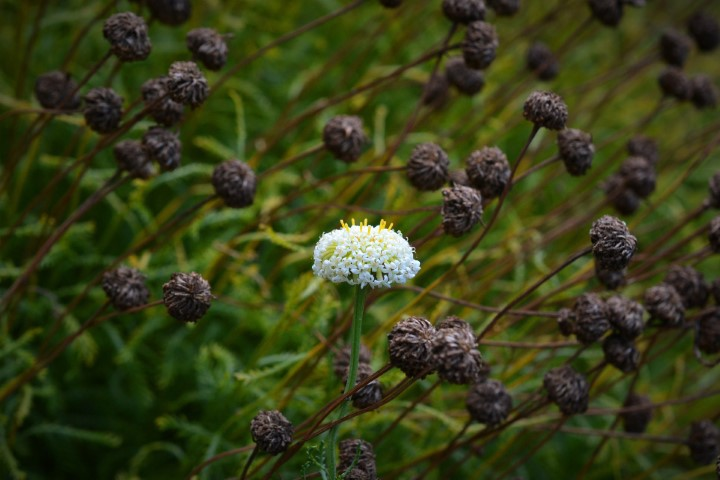

Bild von <a href="https://pixabay.com/de/users/anemone123-2637160/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Anemone123</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1576948">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat
from numpy import power, quantile, mean

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

import keras
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import regularizers
from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

import plotly.express as px
import plotly.subplots as sp

import matplotlib.pyplot as plt

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der Datensatz, der für den Third International Knowledge Discovery and Data Mining Tools Competition verwendet wurde. Die Wettbewerbsaufgabe bestand darin, einen Netzwerk-Intrusion-Detektor zu bauen, ein Vorhersagemodell, das in der Lage ist, zwischen schlechten Verbindungen, sogenannten Intrusionen oder Angriffen, und guten normalen Verbindungen zu unterscheiden. Diese Datenbank enthält einen zu prüfenden Standarddatensatz, der eine Vielzahl von Eindringversuchen umfasst, die in einer militärischen Netzwerkumgebung simuliert wurden.

Der ursprüngliche KDD Cup 1999-Datensatz aus dem  UCI-Repositorium für maschinelles Lernen  enthält 41 Attribute (34 kontinuierlich und 7 kategorial), sie werden jedoch auf 3 Attribute (Dauer, src_bytes, dst_bytes) reduziert.

Da die kontinuierlichen Attributwerte um '0' herum konzentriert sind, haben wir jeden Wert durch y = log(x + 0,1) in einen Wert weit von '0' transformiert.

Aus KDD Cup 1999-Datensatz werden ca. 500k „http“-Dienstdaten verwendet.

Der KDD Cup ist der jährliche Data-Mining- und Knowledge-Discovery-Wettbewerb, der von der ACM Special Interest Group on Knowledge Discovery and Data Mining, der führenden Berufsorganisation von Data-Minern, organisiert wird.


[DataSet](https://www.openml.org/search?type=data&status=active&id=1113)

[Info](http://odds.cs.stonybrook.edu/http-kddcup99-dataset/)


[UCI](https://archive.ics.uci.edu/ml/datasets/kdd+cup+1999+data)

[KDD](https://kdd.org/kdd-cup)



**Datensatz:**

| feature name  | description                                      | type        |
|------------|--------------------------------------------------|-------------|
| duration   | length (number of seconds) of the connection     | continuous  |
| src_bytes  | number of data bytes from source to destination  | continuous  |
| dst_bytes  | number of data bytes from destination to source  | continuous  |

<br>
<br>


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/kddcup1999_xs.csv"
)


<p><font color='black' size="5">
Trennung Data/Target
</font></p>

In [ ]:
data = df.copy()
target = data.pop("Intrusion")

In [ ]:
target.value_counts()


<p><font color='black' size="5">
Trennung Inlier/Outlier
</font></p>

In [ ]:
inlier_data = df[df.Intrusion == 0].copy()
inlier_target = inlier_data.pop("Intrusion")

In [ ]:
outlier_data = df[df.Intrusion == 1].copy()
outlier_target = outlier_data.pop("Intrusion")

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()


<p><font color='black' size="5">
Modellaufbau
</font></p>

In [ ]:
input_dim = inlier_data.shape[1]

**Keras Functional API**

Functional API ermöglicht, Modelle mit komplexeren Topologien wie mehreren Eingängen und Ausgängen oder Modellen mit gemeinsam genutzten Schichten zu erstellen. Die funktionale API wird verwendet, um direkte Verbindungen zwischen den Schichten explizit zu definieren, was mehr Kontrolle und Anpassungsfähigkeit bietet:

In [ ]:
# Erstellen des Input-Layers
input_layer = Input(shape=(input_dim,), name='Input_layer')

In [ ]:
# Erstellen des coder-Layers
coder_layer = Dense(
    units=10,
    activation="relu",
    activity_regularizer=regularizers.l1(10e-5),
    name='coder'
)(input_layer)

In [ ]:
# Erstellen des Decoder-Layers
decoder_layer = Dense(
    units=input_dim,
    activation="sigmoid",
    name='Decoder'
)(coder_layer)

In [ ]:
# Zusammenbau des Autocoders
autocoder = Model(inputs=input_layer, outputs=decoder_layer)

In [ ]:
autocoder.summary()

In [ ]:
# Visualisierung neuronales Netz
plot_model(
    autocoder,
    to_file="nn_structure.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True,
    show_layer_activations=True
)

In [ ]:
# Anzahl Parameter je Layer
for layer in autocoder.layers:
    print(f"{layer.name}: {layer.count_params()} Parameter")


<p><font color='black' size="5">
 Compile
</font></p>

In [ ]:
autocoder.compile(optimizer="adam", loss="mae")

<p><font color='black' size="5">
Callbacks
</font></p>

In [ ]:
early = EarlyStopping(monitor="val_loss", patience=2)

check = ModelCheckpoint(filepath="model.keras", monitor="val_loss", save_best_only=True)


<p><font color='black' size="5">
 Training
</font></p>

In [ ]:
autocoder.fit(
    inlier_data,
    inlier_data,
    epochs=50,
    batch_size=512,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early, check],
)


<p><font color='black' size="5">
Rekonstruktion
</font></p>

In [ ]:
model = load_model("model.keras")

In [ ]:
# Daten durch den trainierten Autocoder laufen lassen, um die rekonstruierten Daten zu erhalten
reconstructed_data = model.predict(data)


<p><font color='black' size="5">
Rekonstruktionsfehler berechnen
</font></p>

In [ ]:
# Berechnen des mittleren quadratischen Fehlers (MAE) zwischen den Originaldaten und den rekonstruierten Daten
# Dies wird für jeden Datenpunkt einzeln durchgeführt, indem die Differenz quadriert und dann gemittelt wird.
# 'axis=1' bedeutet, dass die Operation entlang der Spalten für jede Zeile durchgeführt wird, also für jeden Datenpunkt.
mae = mean(np.power(data - reconstructed_data, 2), axis=1)

# Bestimmen des Schwellenwerts für den MAE, der verwendet wird, um Ausreißer zu identifizieren
# Hier wird der 99.5%-Quantilwert des MAE verwendet, was bedeutet, dass 99.5% der Datenpunkte einen MAE haben,
# der niedriger ist als dieser Schwellenwert. Die Annahme hier ist, dass die oberen 0.5% der Datenpunkte mit dem
# höchsten MAE als Ausreißer betrachtet werden.
mae_threshold = quantile(mae, 0.995)  # Annahme: 0.5% der Daten sind Ausreißer

# Identifizieren der Ausreißer als die Datenpunkte, deren mae den berechneten Schwellenwert überschreitet
# Dies gibt ein boolesches Array zurück, wobei 'True' einen Ausreißer (mae über dem Schwellenwert) darstellt
# und 'False' einen normalen Datenpunkt (mae unter dem Schwellenwert).
outliers_detected = mae > mae_threshold

In [ ]:
DataFrame(outliers_detected).value_counts()

In [ ]:
plt.hist(mae, bins=50)
plt.axvline(mae_threshold, color="r", linestyle="dashed", linewidth=2)
plt.title("Histogramm der Rekonstruktionsfehler")
plt.xlabel("Rekonstruktionsfehler")
plt.ylabel("Anzahl der Datenpunkte")
plt.show()

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Silhouette Koeffizient
</font></p>

In [ ]:
labels = outliers_detected.replace([False, True], [0, 1])


<p><font color='black' size="5">
 ROC AUC
</font></p>

In [ ]:
roc_auc_score(target, labels)


<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target, labels)
plt.rcParams["figure.figsize"] = [5, 5]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target, labels, target_names=["No", "Yes"]))

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data.copy()

# Übernahem Target real & predict
cube["real"] = target
cube["predict"] = labels

In [ ]:
# Erstellung 2D Features über Dimensionsreduktion PCA - unsupervised
from sklearn.decomposition import PCA

pca = PCA()
pca = pca.fit_transform(data)
pca_df = DataFrame(pca)

cube.reset_index(inplace=True)

In [ ]:
# Cube um pca erweitern
cube["PCA1"] = pca_df[0]
cube["PCA2"] = pca_df[1]

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

In [ ]:
# 2 x Scatterplots

cube["real_cat"] = cube["real"].astype(str)
cube["predict_cat"] = cube["predict"].astype(str)

title_ = "Streupunktdiagramm real"
img1 = px.scatter(
    cube, x="PCA1", y="PCA2", color="real_cat", opacity=0.5, width=600, height=600
)

title_ = "Streupunktdiagramm predict"
img2 = px.scatter(
    cube, x="PCA1", y="PCA2", color="predict_cat", opacity=0.5, width=600, height=600
)

fig = sp.make_subplots(
    rows=1, cols=2, subplot_titles=("Scatterplot real", "Scatterplot predict")
)

for trace in img1.data:
    fig.add_trace(trace, row=1, col=1)
for trace in img2.data:
    fig.add_trace(trace, row=1, col=2)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text=title_)

# Plot anzeigen
fig.show()

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>